In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi']     = 120

# Load sample (swap path to full_dataset.pkl once ready)
# Change this line in Cell 1
df = pd.read_pickle('../data/processed/full_dataset.pkl')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print(df.shape)
df.head()

(13377, 8)


,ticker,date,q,transcript,pct_change,direction,year,month
0,PEN,2019-05-07 16:30:00,2019-Q1,Prepared Remarks:\nOperator\nGood afternoon. M...,3.2171,1,2019,5
1,CXW,2019-05-09 11:00:00,2019-Q1,Prepared Remarks:\nOperator\nGood morning. My ...,2.5012,1,2019,5
2,LIN,2019-05-10 09:00:00,2019-Q1,"Prepared Remarks:\nOperator\nGood day, ladies ...",4.0806,1,2019,5
3,SUZ,2019-05-10 13:00:00,2019-Q1,"Prepared Remarks:\nOperator\nGood afternoon, l...",-10.6445,0,2019,5
4,GDS,2019-05-14 08:00:00,2019-Q1,"Prepared Remarks:\nOperator\nHello, ladies and...",5.7726,1,2019,5


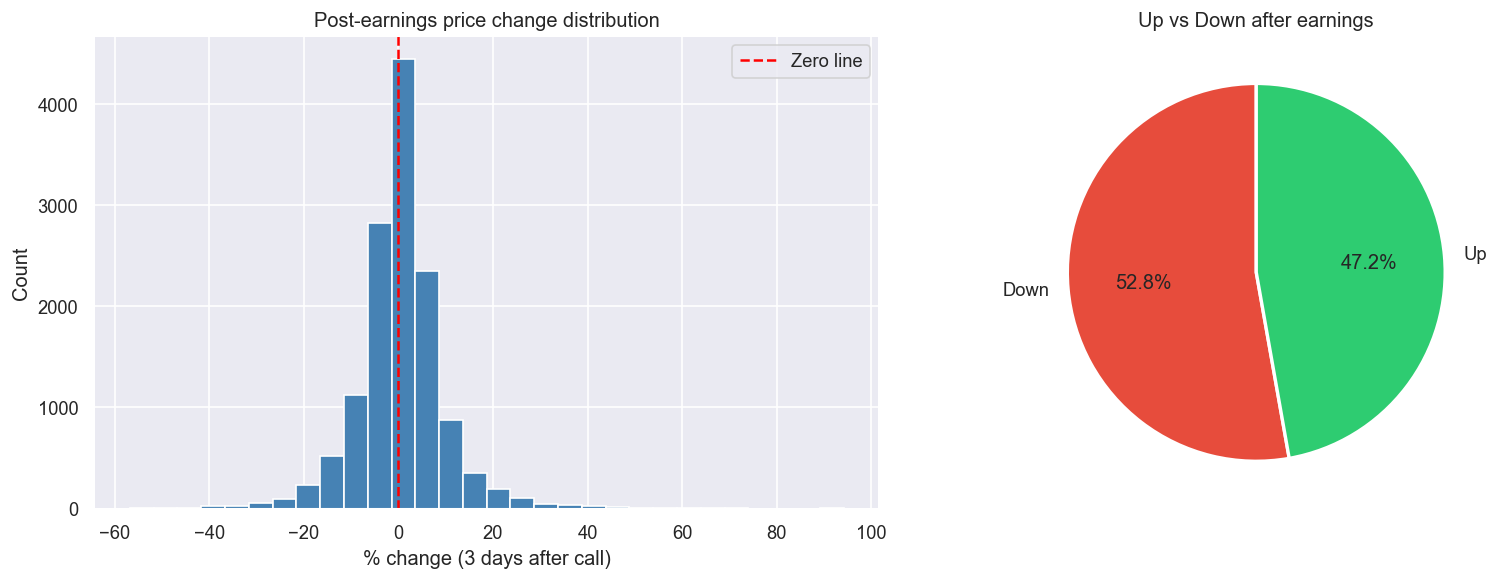

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of % change
axes[0].hist(df['pct_change'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero line')
axes[0].set_title('Post-earnings price change distribution')
axes[0].set_xlabel('% change (3 days after call)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Up vs Down pie
counts = df['direction'].value_counts()
axes[1].pie(counts, labels=['Down', 'Up'], autopct='%1.1f%%',
            colors=['#e74c3c','#2ecc71'], startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Up vs Down after earnings')

plt.tight_layout()
plt.savefig('../data/processed/eda_price_distribution.png', bbox_inches='tight')
plt.show()

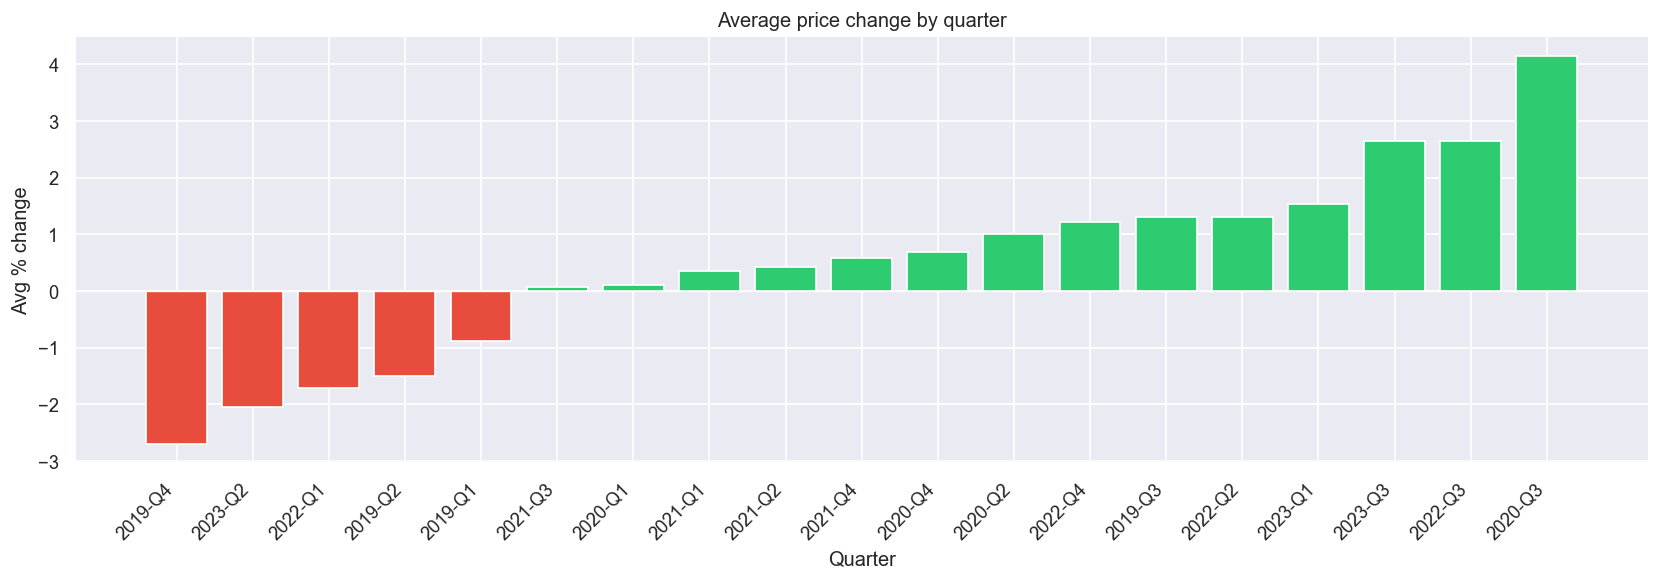

In [3]:
quarter_stats = df.groupby('q')['pct_change'].agg(['mean','median','count']).reset_index()
quarter_stats = quarter_stats[quarter_stats['count'] >= 3].sort_values('mean')

plt.figure(figsize=(14, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in quarter_stats['mean']]
bars = plt.bar(quarter_stats['q'], quarter_stats['mean'], color=colors, edgecolor='white')
plt.axhline(0, color='white', linewidth=0.8)
plt.title('Average price change by quarter')
plt.xlabel('Quarter')
plt.ylabel('Avg % change')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/eda_by_quarter.png', bbox_inches='tight')
plt.show()

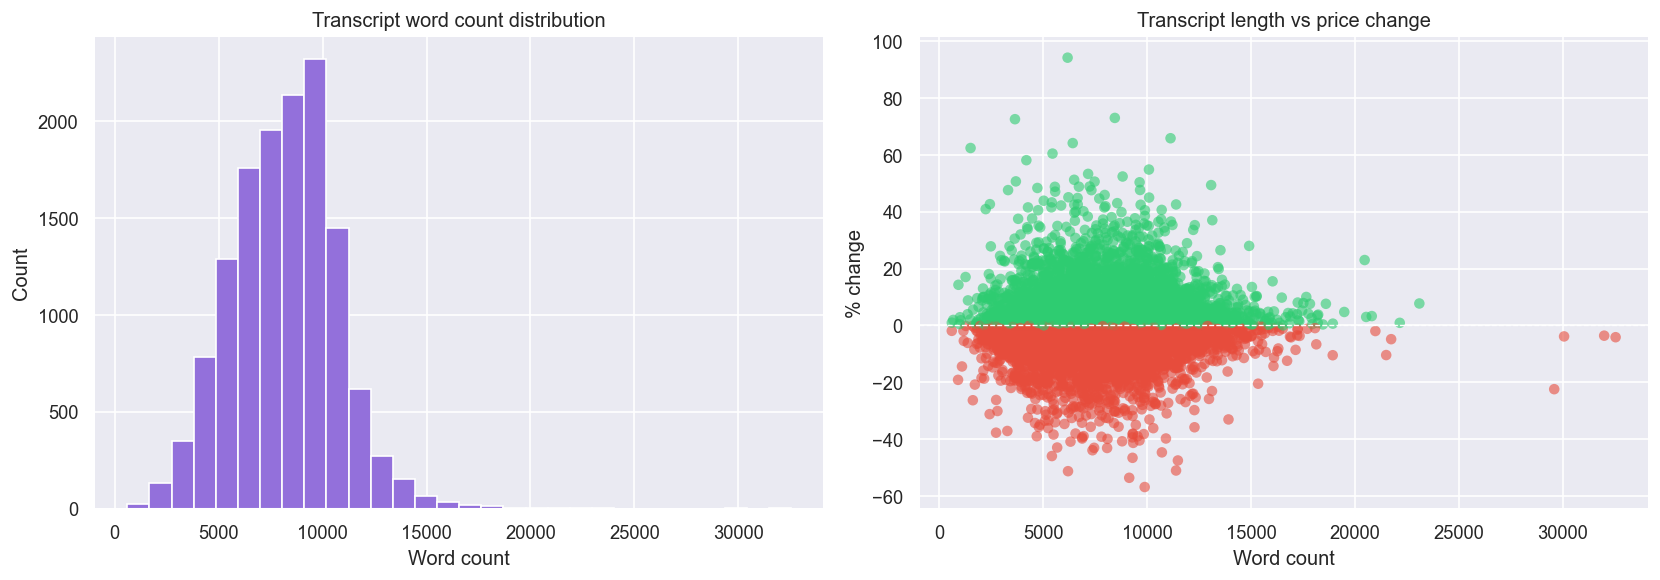

Avg transcript length: 8178 words
Min: 605 | Max: 32545


In [4]:
df['transcript_length'] = df['transcript'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length distribution
axes[0].hist(df['transcript_length'], bins=30, color='mediumpurple', edgecolor='white')
axes[0].set_title('Transcript word count distribution')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Count')

# Length vs price change scatter
axes[1].scatter(df['transcript_length'], df['pct_change'],
                c=df['direction'].map({1:'#2ecc71', 0:'#e74c3c'}),
                alpha=0.6, edgecolors='none', s=40)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title('Transcript length vs price change')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('% change')

plt.tight_layout()
plt.savefig('../data/processed/eda_transcript_length.png', bbox_inches='tight')
plt.show()

print(f"Avg transcript length: {df['transcript_length'].mean():.0f} words")
print(f"Min: {df['transcript_length'].min()} | Max: {df['transcript_length'].max()}")

In [5]:
print("🚀 Top 10 biggest gains after earnings:")
print(df.nlargest(10, 'pct_change')[['ticker','date','q','pct_change']].to_string(index=False))

print("\n📉 Top 10 biggest drops after earnings:")
print(df.nsmallest(10, 'pct_change')[['ticker','date','q','pct_change']].to_string(index=False))

🚀 Top 10 biggest gains after earnings:
ticker                date       q  pct_change
  MGNI 2022-11-09 16:30:00 2022-Q3     94.1176
   TDC 2021-02-04 17:00:00 2020-Q4     72.9390
  HYFM 2022-08-09 16:30:00 2022-Q2     72.4907
  SNAP 2022-02-03 17:00:00 2021-Q4     65.7959
  TUYA 2022-03-14 20:00:00 2021-Q4     64.0909
   GME 2022-03-17 17:00:00 2021-Q4     62.3603
   RLX 2022-03-11 07:00:00 2021-Q4     60.4027
  FUTU 2022-03-11 07:30:00 2021-Q4     58.0808
     U 2022-11-09 18:00:00 2022-Q3     54.7907
  UPWK 2020-11-04 17:00:00 2020-Q3     53.2641

📉 Top 10 biggest drops after earnings:
ticker                date       q  pct_change
  SLQT 2022-02-07 17:00:00 2022-Q2    -56.8147
  AMPL 2022-02-16 17:00:00 2021-Q4    -53.5689
   LAW 2022-08-11 17:00:00 2022-Q2    -51.2431
  UPST 2022-05-09 16:30:00 2022-Q1    -51.0048
  GDRX 2022-02-28 17:00:00 2021-Q4    -47.4817
  AFIB 2021-11-11 16:30:00 2021-Q3    -46.5465
  GOCO 2022-08-15 17:00:00 2022-Q2    -45.9276
  STNE 2021-11-16 17:00:00 2

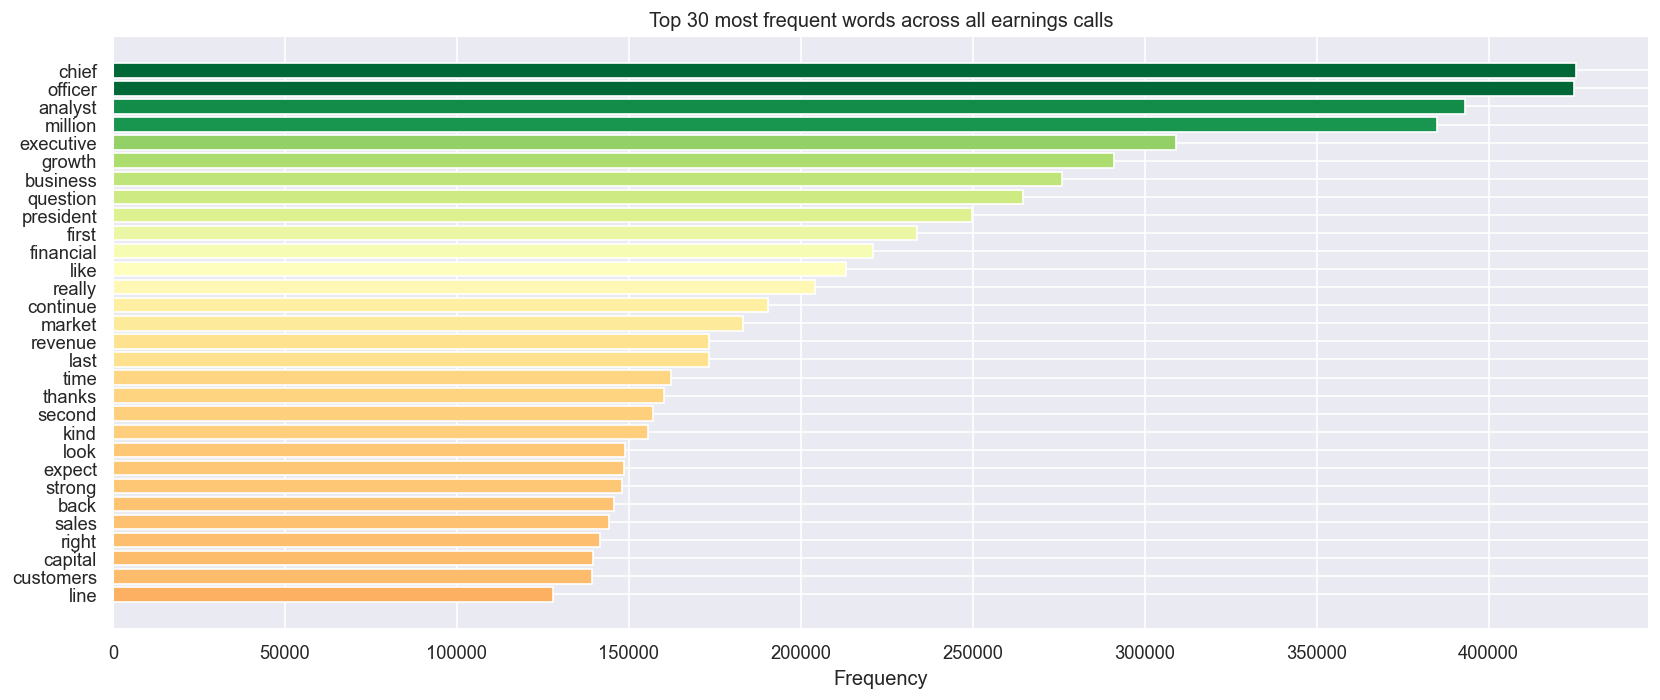

In [6]:
import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOP = set(stopwords.words('english'))
# Add finance-specific filler words to remove
EXTRA_STOP = {'quarter','year','company','think','going','know',
              'well','said','one','also','would','could','get',
              'thank','questions','prepared','remarks','operator',
              'good','day','morning','evening','call','next'}
STOP.update(EXTRA_STOP)

def extract_keywords(text, n=50):
    words = re.findall(r'\b[a-z]{4,}\b', text.lower())
    words = [w for w in words if w not in STOP]
    return Counter(words).most_common(n)

# Combine all transcripts
all_text = ' '.join(df['transcript'].dropna().tolist())
top_words = extract_keywords(all_text, n=30)

words, counts = zip(*top_words)
plt.figure(figsize=(14, 6))
colors = plt.cm.RdYlGn([c/max(counts) for c in counts])
bars = plt.barh(words[::-1], counts[::-1], color=colors[::-1])
plt.title('Top 30 most frequent words across all earnings calls')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('../data/processed/eda_keywords.png', bbox_inches='tight')
plt.show()

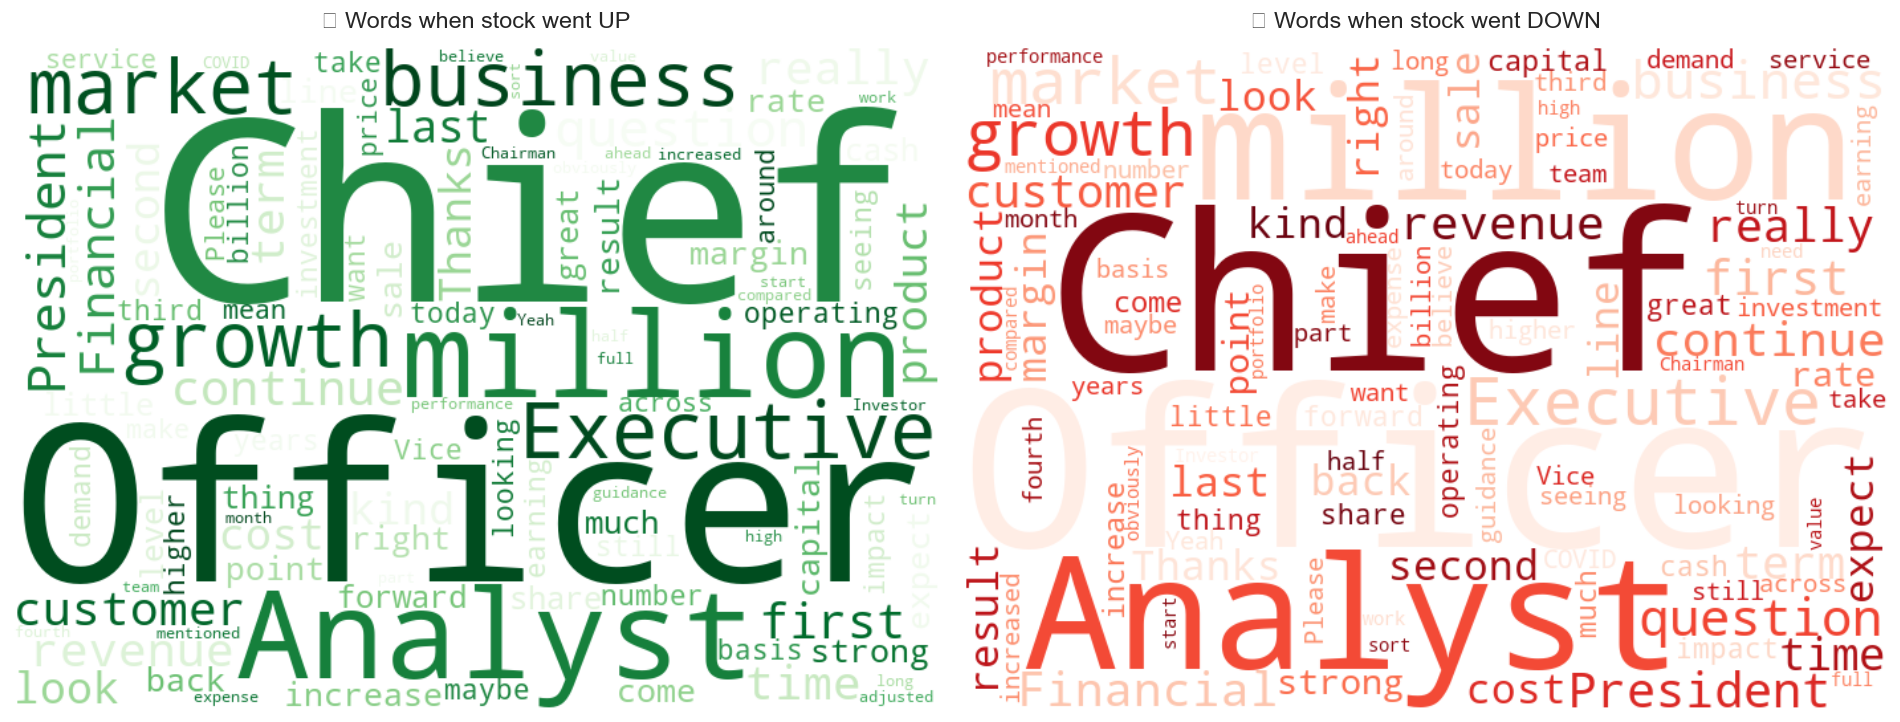

In [7]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, label, title, cmap in zip(
    axes,
    [1, 0],
    ['📈 Words when stock went UP', '📉 Words when stock went DOWN'],
    ['Greens', 'Reds']
):
    subset = df[df['direction'] == label]
    text   = ' '.join(subset['transcript'].dropna().tolist())
    
    # Clean text
    text = re.sub(r'\b\w{1,3}\b', '', text)
    for w in STOP:
        text = re.sub(rf'\b{w}\b', '', text, flags=re.IGNORECASE)
    
    wc = WordCloud(
        width=700, height=500,
        background_color='white',
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, pad=12)

plt.tight_layout()
plt.savefig('../data/processed/eda_wordclouds.png', bbox_inches='tight')
plt.show()

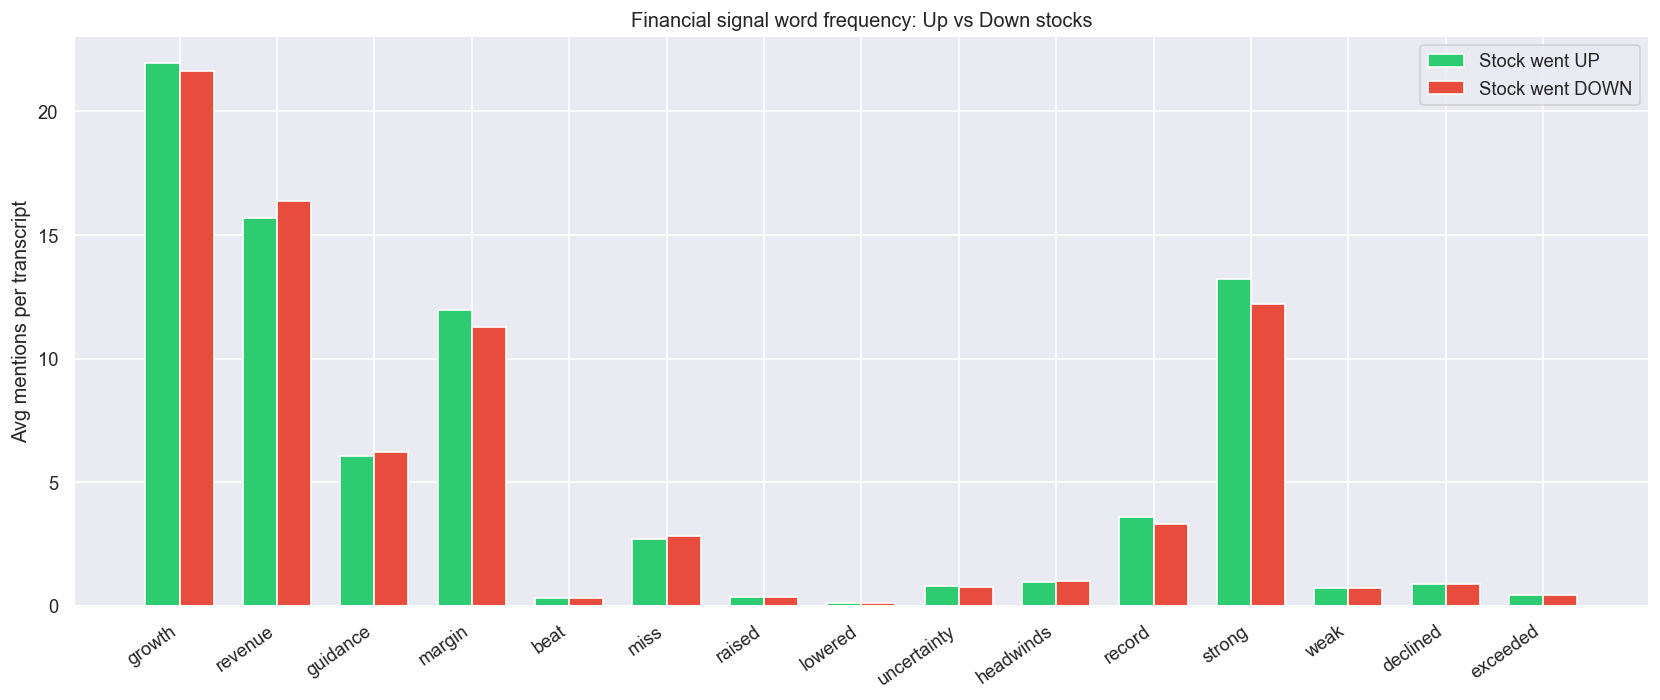

In [8]:
# Track words that matter in finance
signal_words = ['growth', 'revenue', 'guidance', 'margin', 'beat',
                'miss', 'raised', 'lowered', 'uncertainty', 'headwinds',
                'record', 'strong', 'weak', 'declined', 'exceeded']

signal_counts = {'word': [], 'up_freq': [], 'down_freq': []}

for word in signal_words:
    up_text   = ' '.join(df[df['direction']==1]['transcript'].str.lower())
    down_text = ' '.join(df[df['direction']==0]['transcript'].str.lower())
    
    up_count   = up_text.count(word)   / max(len(df[df['direction']==1]), 1)
    down_count = down_text.count(word) / max(len(df[df['direction']==0]), 1)
    
    signal_counts['word'].append(word)
    signal_counts['up_freq'].append(round(up_count, 2))
    signal_counts['down_freq'].append(round(down_count, 2))

sig_df = pd.DataFrame(signal_counts)

x = np.arange(len(signal_words))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, sig_df['up_freq'],   width, label='Stock went UP',   color='#2ecc71')
ax.bar(x + width/2, sig_df['down_freq'], width, label='Stock went DOWN', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(signal_words, rotation=35, ha='right')
ax.set_title('Financial signal word frequency: Up vs Down stocks')
ax.set_ylabel('Avg mentions per transcript')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/eda_signal_words.png', bbox_inches='tight')
plt.show()